## Загрузка и проверка eval вопросов из Excel
Работаем с `questions/eval_questions_final.xlsx`, где два листа: Sheet1 (сырые/сгенерированные) и Sheet2 (проверенные). Ниже загружаем оба, чистим строки/списки и считаем сводку по ошибкам в логике.


In [1]:
import pandas as pd
import ast
from pathlib import Path

DATA_PATH = Path("eval_questions_final.xlsx")
assert DATA_PATH.exists(), f"Файл не найден: {DATA_PATH}"

sheets_raw = pd.read_excel(DATA_PATH, sheet_name=None)
# помечаем источник: Sheet1 = генерация, Sheet2 = проверенные
sheets_raw = {
    name: df.assign(source_sheet=name, is_generated=(name.lower() == "sheet1"))
    for name, df in sheets_raw.items()
}
list(sheets_raw.keys())


['Sheet1', 'Sheet2']

In [2]:
def parse_list(val):
    if pd.isna(val):
        return []
    if isinstance(val, list):
        return val
    try:
        parsed = ast.literal_eval(str(val))
        if isinstance(parsed, list):
            return parsed
        return [parsed]
    except Exception:
        return [str(val)]


def clean_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # убираем пустые строки по Сам_запрос (если колонка есть)
    if "Сам_запрос" in df.columns:
        df = df[df["Сам_запрос"].astype(str).str.strip() != ""]
    for col in ["answerable", "question_type", "difficulty", "supporting_quote"]:
        if col in df.columns:
            df[col] = df[col].apply(parse_list)
    if "Ошибка_в_логике" in df.columns:
        df["Ошибка_в_логике"] = df["Ошибка_в_логике"].fillna("")
    return df.reset_index(drop=True)

sheets_clean = {name: clean_df(df) for name, df in sheets_raw.items()}

for name, df in sheets_clean.items():
    print(f"Sheet: {name}, rows={len(df)}")
    flagged = (df["Ошибка_в_логике"].astype(str).str.strip() != "").sum() if "Ошибка_в_логике" in df else 0
    print(f"  flagged (Ошибка_в_логике != ''): {flagged}")

# объединяем оба листа в один датасет
combined_df = pd.concat(sheets_clean.values(), ignore_index=True)
# добавляем колонку source: generated для Sheet1, selfmade для Sheet2/прочих
combined_df["source"] = combined_df.apply(
    lambda r: "generated" if str(r.get("source_sheet", "")).lower() == "sheet1" else "selfmade",
    axis=1,
)
print("Общий датасет:", combined_df.shape)

# финальный (для дальнейшей аналитики) оставляем как проверенный, но source уже есть
final_df = sheets_clean["Sheet2"] if "Sheet2" in sheets_clean else next(iter(sheets_clean.values()))
print("\nФинальный датасет (проверенный):", final_df.shape)
final_df.head(3)


Sheet: Sheet1, rows=114
  flagged (Ошибка_в_логике != ''): 1
Sheet: Sheet2, rows=29
  flagged (Ошибка_в_логике != ''): 2
Общий датасет: (143, 18)

Финальный датасет (проверенный): (29, 15)


,Интернациональный/РФ,Вид_катания,Профессиональный,Pdf_name,Ошибка_в_логике,Кол-во_вопросов_в_запросе,Сам_запрос,Ожидаемый_ответ,answerable,question_type,difficulty,supporting_quote,chunk_id,source_sheet,is_generated
0,РФ,Одиночное,Профессионалы,pdf_rules\Профессионалы\ТЕХНИЧЕСКИЕ ТРЕБОВАНИЯ...,,1.0,Какие элементы нельзя выполнять в программе?,прыжки типа сальто; поддержки с неправильными ...,[],[],[],[],NaN,Sheet2,False
1,РФ,Одиночное,Профессионалы,pdf_rules\Профессионалы\ТЕХНИЧЕСКИЕ ТРЕБОВАНИЯ...,,1.0,Какие элементы запроещены?,прыжки типа сальто; поддержки с неправильными ...,[],[],[],[],NaN,Sheet2,False
2,РФ,Одиночное,Профессионалы,pdf_rules\Профессионалы\ТЕХНИЧЕСКИЕ ТРЕБОВАНИЯ...,,2.0,сколько прыжков должно быть в одиночном катани...,"максимум 7 прыжков, один из которых аксель; н...",[],[],[],[],NaN,Sheet2,False


In [3]:
# Быстрая аналитика по финальному датасету

def coverage(df: pd.DataFrame, by: str) -> pd.DataFrame:
    return (
        df.groupby(by)
        .size()
        .reset_index(name="cnt")
        .sort_values("cnt", ascending=False)
        .reset_index(drop=True)
    )

summary = {
    "docs": coverage(final_df, "Pdf_name") if "Pdf_name" in final_df else pd.DataFrame(),
    "discipline": coverage(final_df, "Вид_катания") if "Вид_катания" in final_df else pd.DataFrame(),
    "audience": coverage(final_df, "Профессиональный") if "Профессиональный" in final_df else pd.DataFrame(),
    "country": coverage(final_df, "Интернациональный/РФ") if "Интернациональный/РФ" in final_df else pd.DataFrame(),
    "num_questions": coverage(final_df, "Кол-во_вопросов_в_запросе") if "Кол-во_вопросов_в_запросе" in final_df else pd.DataFrame(),
}

# превращаем списковые поля в строки для удобства экспорта
export_df = final_df.copy()
for col in ["answerable", "question_type", "difficulty", "supporting_quote"]:
    if col in export_df.columns:
        export_df[col] = export_df[col].apply(lambda x: ", ".join(map(str, x)) if isinstance(x, list) else x)

flagged = final_df[final_df.get("Ошибка_в_логике", "").astype(str).str.strip() != ""]
print(f"Финальный датасет: {len(final_df)} строк")
print(f"Проблемных по логике: {len(flagged)}")

export_path = DATA_PATH.with_name("eval_questions_final_clean.csv")
export_df.to_csv(export_path, index=False)
# сохраним объединённый датасет с source
combined_path = DATA_PATH.with_name("eval_questions_final_with_source.csv")
combined_df.to_csv(combined_path, index=False)
print(f"Сохранено: {export_path} и {combined_path}")

for name, table in summary.items():
    if not table.empty:
        print(f"\n=== {name} ===")
        display(table.head(10))

if not flagged.empty:
    display(flagged[["Pdf_name", "Сам_запрос", "Ошибка_в_логике"]].head(10))


Финальный датасет: 29 строк
Проблемных по логике: 2
Сохранено: eval_questions_final_clean.csv и eval_questions_final_with_source.csv

=== docs ===


,Pdf_name,cnt
0,pdf_rules\Профессионалы\ТЕХНИЧЕСКИЕ ТРЕБОВАНИЯ...,9
1,ПРАВИЛА ВИДА СПОРТА фигурное катание 2024.pdf,7
2,ПРЕДВАРИТЕЛЬНЫЕ_Технические_требования_взрослы...,6
3,РУКОВОДСТВО ТЕХНИЧЕСКОЙ КОМИССИИ ПО ОДИНОЧНОМУ...,4
4,ПРЕДВАРИТЕЛЬНЫЕ_Технические_требования_взрослы...,1
5,Программа_тестирования_для_любителей.pdf,1
6,Руководство технических бригад Синхронное ката...,1



=== discipline ===


,Вид_катания,cnt
0,общее,15
1,Одиночное,5
2,одиночное,3
3,парное,2
4,синхронное,2
5,Танцы на льду,1
6,Общее,1



=== audience ===


...


=== country ===


,Интернациональный/РФ,cnt
0,РФ,25
1,ISU,4



=== num_questions ===


,Кол-во_вопросов_в_запросе,cnt
0,1.0,18
1,2.0,7
2,3.0,1


,Pdf_name,Сам_запрос,Ошибка_в_логике
6,pdf_rules\Профессионалы\ТЕХНИЧЕСКИЕ ТРЕБОВАНИЯ...,как получиь 10 уровень за вращение?,да
7,pdf_rules\Профессионалы\ТЕХНИЧЕСКИЕ ТРЕБОВАНИЯ...,Как правильно выполнять выбросы в танцах на льду?,да


In [4]:
# уберем вопросы, которые нам не понравились 
print(combined_df.shape)
combined_df = combined_df[combined_df['reason_skip'].isna()]
print(combined_df.shape)

(143, 18)
(136, 18)


In [5]:
combined_df.isna().sum()

Интернациональный/РФ           6
Вид_катания                    6
Профессиональный               6
Pdf_name                       6
Ошибка_в_логике                0
Кол-во_вопросов_в_запросе      9
Сам_запрос                     6
Ожидаемый_ответ                6
answerable                     0
question_type                  0
difficulty                     0
supporting_quote               0
chunk_id                      35
Unnamed: 13                  136
reason_skip                  136
source_sheet                   0
is_generated                   0
source                         0
dtype: int64

In [6]:
combined_df[combined_df['Профессиональный'].isna()]

,Интернациональный/РФ,Вид_катания,Профессиональный,Pdf_name,Ошибка_в_логике,Кол-во_вопросов_в_запросе,Сам_запрос,Ожидаемый_ответ,answerable,question_type,difficulty,supporting_quote,chunk_id,Unnamed: 13,reason_skip,source_sheet,is_generated,source
27,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,[],[],[],[],NaN,NaN,NaN,Sheet1,True,generated
28,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,[],[],[],[],NaN,NaN,NaN,Sheet1,True,generated
29,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,[],[],[],[],NaN,NaN,NaN,Sheet1,True,generated
30,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,[],[],[],[],NaN,NaN,NaN,Sheet1,True,generated
31,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,[],[],[],[],NaN,NaN,NaN,Sheet1,True,generated
32,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,[],[],[],[],NaN,NaN,NaN,Sheet1,True,generated


In [7]:
#убираем мусор
combined_df = combined_df[~combined_df['Профессиональный'].isna()]
combined_df.isna().sum()

Интернациональный/РФ           0
Вид_катания                    0
Профессиональный               0
Pdf_name                       0
Ошибка_в_логике                0
Кол-во_вопросов_в_запросе      3
Сам_запрос                     0
Ожидаемый_ответ                0
answerable                     0
question_type                  0
difficulty                     0
supporting_quote               0
chunk_id                      29
Unnamed: 13                  130
reason_skip                  130
source_sheet                   0
is_generated                   0
source                         0
dtype: int64

In [8]:
for q in combined_df[combined_df['Кол-во_вопросов_в_запросе'].isna()]['Сам_запрос']:
    print(q)

Как правильно выполнять выбросы в танцах на льду?
какие танцы есть в парном катании? чем они отличаются?
в какой категории любительского катания можно выполнять перекидной прыжок и он будет засчитываться?


In [9]:
combined_df.loc[121, 'Кол-во_вопросов_в_запросе'] = 1
combined_df.loc[122, 'Кол-во_вопросов_в_запросе'] = 2
combined_df.loc[127, 'Кол-во_вопросов_в_запросе'] = 1

In [10]:
combined_df.drop(columns=['Unnamed: 13'], inplace=True)

In [11]:
combined_df.isna().sum()

Интернациональный/РФ           0
Вид_катания                    0
Профессиональный               0
Pdf_name                       0
Ошибка_в_логике                0
Кол-во_вопросов_в_запросе      0
Сам_запрос                     0
Ожидаемый_ответ                0
answerable                     0
question_type                  0
difficulty                     0
supporting_quote               0
chunk_id                      29
reason_skip                  130
source_sheet                   0
is_generated                   0
source                         0
dtype: int64

In [12]:
# Оставим только те строки, где answerable полностью состоит из True или пусто
def all_true_or_empty(val):
    # Пустой список или NaN
    if val == [] or (isinstance(val, float) and pd.isna(val)):
        return True
    # Только True значения в списке
    if isinstance(val, list) and all(x is True for x in val):
        return True
    return False

filtered_df = combined_df[combined_df['answerable'].apply(all_true_or_empty)]

print(f"Исходное количество строк: {len(combined_df)}")
print(f"Осталось после фильтрации: {len(filtered_df)}")
print(f"Потеряно строк: {len(combined_df) - len(filtered_df)}")

Исходное количество строк: 130
Осталось после фильтрации: 80
Потеряно строк: 50


In [43]:
filtered_df.loc[
    (filtered_df['Профессиональный'] == 'isu') | (filtered_df['Профессиональный'] == 'Профессионалы'),
    'Профессиональный'
] = 'профессионалы'

In [44]:
filtered_df.isna().sum()

Интернациональный/РФ          0
Вид_катания                   0
Профессиональный              0
Pdf_name                      0
Ошибка_в_логике               0
Кол-во_вопросов_в_запросе     0
Сам_запрос                    0
Ожидаемый_ответ               0
answerable                    0
question_type                 0
difficulty                    0
supporting_quote              0
chunk_id                     29
reason_skip                  80
source_sheet                  0
is_generated                  0
source                        0
query_id                      0
dtype: int64

In [45]:
filtered_df.to_csv('filtered_df.csv', index=False)

In [46]:
filtered_df['query_id'] = range(len(filtered_df))

/tmp/ipykernel_2039667/3363869171.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['query_id'] = range(len(filtered_df))


я хочу оценить качество ретривера 

всё это на разных top_k (пусть это будет список, но по умолчанию top_k = [5])


1) MRR
2) AUC
3) Hit_rate
4) NDCG
5) Recall



In [47]:
# Конфиг для оценки retriever (используем готовый RetrieverFS)
import math
import pandas as pd
import sys
import os

# рабочая директория, чтобы относительные пути retriever.py находили индекс
os.chdir("/home/b.tolstokulakov/study/RAG-AI-Sport-Support")

# подключаем модуль retriever.py
sys.path.append("/home/b.tolstokulakov/study/RAG-AI-Sport-Support")
from app.rag.retriever import RetrieverFS

TOP_K_LIST = [10]
retriever_fs = RetrieverFS(top_k=max(TOP_K_LIST))


def norm_chunk_id(val):
    if pd.isna(val):
        return None
    # 3.0 -> "3"
    try:
        if float(val).is_integer():
            return str(int(float(val)))
    except Exception:
        pass
    return str(val)


def extract_chunk_id(doc):
    # пробуем несколько ключей метаданных
    for key in ["chunk_id", "id", "chunk", "chunkId"]:
        if key in doc.metadata and doc.metadata[key] is not None:
            return norm_chunk_id(doc.metadata[key])
    return None

# Сабсеты
has_chunk_df = filtered_df[filtered_df["chunk_id"].notna()].copy()
no_chunk_df = filtered_df[filtered_df["chunk_id"].isna()].copy()
print(f"Всего в filtered_df: {len(filtered_df)}")
print(f"c chunk_id: {len(has_chunk_df)}, без chunk_id: {len(no_chunk_df)}")


'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 0c872578-1451-4f8e-82ef-a4dc6164676d)')' thrown while requesting HEAD https://huggingface.co/BAAI/bge-m3/resolve/main/./config_sentence_transformers.json
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 9c052305-9829-4e3c-9ac7-1d934952c0ca)')' thrown while requesting HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-m3/5617a9f61b028005a4858fdac845db406aefb181/config_sentence_transformers.json
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: babc8f05-1002-4d15-b0d4-c0f807d9899e)')' thrown while requesting HEAD https://huggingface.co/BAAI/bge-m3/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].


Всего в filtered_df: 80
c chunk_id: 51, без chunk_id: 29


In [48]:
# Метрики для запросов с известным chunk_id (rank-based)

def text_match_soft(targets, doc_text, min_overlap=0.2):
    if not targets:
        return False
    doc_low = doc_text.lower()
    # точные подстроки
    if any(t in doc_low for t in targets):
        return True
    # словесное перекрытие
    import re
    words_doc = set(w for w in re.findall(r"\w+", doc_low) if len(w) > 3)
    for t in targets:
        words_t = set(w for w in re.findall(r"\w+", t) if len(w) > 3)
        if not words_t:
            continue
        overlap = len(words_doc & words_t) / len(words_t)
        if overlap >= min_overlap:
            return True
    return False


def build_labels(row, docs, rel_id=None, use_chunk_id=True, soft=False):
    labels = []
    # тексты ответа/цитат для фолбека
    truth_texts = []
    if not pd.isna(row.get("Ожидаемый_ответ", None)):
        truth_texts.append(str(row["Ожидаемый_ответ"]))
    if "supporting_quote" in row and isinstance(row["supporting_quote"], list):
        truth_texts.extend([str(x) for x in row["supporting_quote"] if x])
    lowered_truth = [t.lower() for t in truth_texts if t]

    for d in docs:
        lab = 0
        if use_chunk_id and rel_id is not None:
            cid = extract_chunk_id(d)
            if cid == rel_id:
                lab = 1
        if lab == 0 and lowered_truth:
            dtext = d.page_content.lower()
            if soft:
                if text_match_soft(lowered_truth, dtext):
                    lab = 1
            else:
                if any(t in dtext for t in lowered_truth):
                    lab = 1
        labels.append(lab)
    return labels


def metrics_from_labels(labels):
    if not labels:
        return dict(rank=-1, MRR=0.0, Hit_rate=0.0, Recall=0.0, NDCG=0.0, AUC=0.0)
    try:
        rank = labels.index(1)
    except ValueError:
        rank = -1
    if rank == -1:
        return dict(rank=-1, MRR=0.0, Hit_rate=0.0, Recall=0.0, NDCG=0.0, AUC=0.0)
    k = len(labels)
    mrr = 1.0 / (rank + 1)
    hit = 1.0
    recall = 1.0  # один релевантный
    ndcg = 1.0 / math.log2(rank + 2)
    auc = (k - rank) / k
    return dict(rank=rank, MRR=mrr, Hit_rate=hit, Recall=recall, NDCG=ndcg, AUC=auc)


def eval_rank_metrics(df: pd.DataFrame, retriever_fs: RetrieverFS, top_k_list=TOP_K_LIST):
    rows = []
    meta_cols = [c for c in df.columns if c not in {"Сам_запрос", "chunk_id"}]

    for k in top_k_list:
        retriever_fs.top_k = k
        for _, row in df.iterrows():
            query = row["Сам_запрос"]
            rel_id = norm_chunk_id(row["chunk_id"])
            docs = retriever_fs.vectorstore.similarity_search(query=query, k=k)

            labels = build_labels(row, docs, rel_id=rel_id, use_chunk_id=True)
            metrics = metrics_from_labels(labels)

            base_row = {
                "query": query,
                "chunk_id": rel_id,
                "k": k,
                "rank": metrics["rank"],
                "MRR": metrics["MRR"],
                "Hit_rate": metrics["Hit_rate"],
                "Recall": metrics["Recall"],
                "NDCG": metrics["NDCG"],
                "AUC": metrics["AUC"],
                "retrieved_chunk_ids": [extract_chunk_id(d) for d in docs],
                "retrieved_texts": [d.page_content for d in docs],
                "labels": labels,
                "origin": "has_chunk",
            }
            for c in meta_cols:
                base_row[c] = row.get(c)
            rows.append(base_row)

    per_query = pd.DataFrame(rows)
    summary = per_query.groupby("k")[["MRR", "Hit_rate", "Recall", "NDCG", "AUC"]].mean().reset_index()
    return per_query, summary


per_query_rank, summary_rank = eval_rank_metrics(has_chunk_df, retriever_fs, TOP_K_LIST)
print("Перезапросов с gt chunk_id:", len(has_chunk_df))
display(summary_rank)
# показываем с текстами для ручной проверки
display(per_query_rank.head())
display(per_query_rank[["query", "chunk_id", "retrieved_chunk_ids", "retrieved_texts"]].head(3))


Перезапросов с gt chunk_id: 51


,k,MRR,Hit_rate,Recall,NDCG,AUC
0,10,0.236897,0.470588,0.470588,0.290975,0.331373


,query,chunk_id,k,rank,MRR,Hit_rate,Recall,NDCG,AUC,retrieved_chunk_ids,...,Ожидаемый_ответ,answerable,question_type,difficulty,supporting_quote,reason_skip,source_sheet,is_generated,source,query_id
0,Я только начал интересоваться фигурным катание...,Figure_Skating_Media_Guide_2024-25__90,10,0,1.0,1.0,1.0,1.0,1.0,"[None, None, None, None, None, None, None, Non...",...,"Каори Сакамото\nЯпония, США, Корея, Россия, Ка...","[True, True, True]","[fact, multi-hop, fact]","[easy, medium, easy]","[Kaori Sakamoto (JPN), Saitama (JPN), 2020 Mon...",NaN,Sheet1,True,generated,0
1,Я пытаюсь разобраться в фигурном катании и хот...,KeyPointsandKeyPointsFeaturesforJuniorPatternD...,10,-1,0.0,0.0,0.0,0.0,0.0,"[None, None, None, None, None, None, None, Non...",...,Правильное размещение ног и правильный перекре...,"[True, True, True]","[fact, procedure, exception]","[medium, medium, medium]",[Correct Foot placement 2. Correct Cross in fr...,NaN,Sheet1,True,generated,1
2,Я недавно начал интересоваться фигурным катани...,PATTERNDANCES202324NOVICE070475800_17327128449...,10,-1,0.0,0.0,0.0,0.0,0.0,"[None, None, None, None, None, None, None, Non...",...,"Fourteenstep ISU Ice, European Waltz ISU Ice, ...",[True],[multi-hop],[medium],[the 6th (last) tune of the Fourteenstep ISU I...,NaN,Sheet1,True,generated,2
3,Я пытаюсь разобраться в технике фигурного ката...,SPComponentCharts20240387849001741256145-036__35,10,-1,0.0,0.0,0.0,0.0,0.0,"[None, None, None, None, None, None, None, Non...",...,Способность фигуристов выполнять репертуар шаг...,"[True, True, True]","[definition, fact, definition]","[medium, medium, easy]",[Определение: способность фигуристов выполнять...,NaN,Sheet1,True,generated,3
4,Я пытаюсь разобраться в фигурном катании и у м...,SPComponentCharts2024064619000_17327068477733__35,10,-1,0.0,0.0,0.0,0.0,0.0,"[None, None, None, None, None, None, None, Non...",...,Это способность исполнителя выполнять репертуа...,"[True, True, True]","[definition, fact, definition]","[medium, easy, medium]",[Определение: способность фигуристов исполнять...,NaN,Sheet1,True,generated,4


,query,chunk_id,retrieved_chunk_ids,retrieved_texts
0,Я только начал интересоваться фигурным катание...,Figure_Skating_Media_Guide_2024-25__90,"[None, None, None, None, None, None, None, Non...",[Year 2024 2023 2022 2021 2020 2019 2018 2017 ...
1,Я пытаюсь разобраться в фигурном катании и хот...,KeyPointsandKeyPointsFeaturesforJuniorPatternD...,"[None, None, None, None, None, None, None, Non...",[| поднимаемый фигурист ...
2,Я недавно начал интересоваться фигурным катани...,PATTERNDANCES202324NOVICE070475800_17327128449...,"[None, None, None, None, None, None, None, Non...",[В сезоне 2025/2026 фигуристы должны предостав...


In [49]:
# Запросы без chunk_id: оценка через LLM (по ожидаемому ответу)
import os
import textwrap
from tqdm import tqdm

RUN_LLM = True  # включи True, чтобы реально дергать LLM
LLM_MODEL = os.getenv("LLM_MODEL", "openai/gpt-4o-mini")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
BASE_URL = os.getenv("OPENAI_BASE_URL") 
TOP_K_LLM = 10

try:
    import openai
except Exception:
    if RUN_LLM:
        raise
    else:
        openai = None


def llm_score_retrieval(query: str, expected_answer: str, docs_text: str, model: str = LLM_MODEL) -> float:
    """Возвращает оценку 0..1, насколько retrieval дал полезный контекст."""
    client = openai.OpenAI(api_key=OPENAI_API_KEY, base_url=BASE_URL)
    system = "Ты проверяешь, насколько извлечённые фрагменты помогут ответить на вопрос. Выдай только число от 0 до 1."
    user = textwrap.dedent(
        f"""
        Вопрос: {query}
        Ожидаемый ответ: {expected_answer}
        Извлечённые фрагменты:
        {docs_text}
        Оцени, даст ли это правильно ответить. Верни только число 0..1.
        """
    ).strip()
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "system", "content": system}, {"role": "user", "content": user}],
        temperature=0,
        max_tokens=10,
    )
    txt = resp.choices[0].message.content.strip()
    try:
        return float(txt)
    except Exception:
        return 0.0


def llm_label_docs(query: str, expected_answer: str, docs: list[str], model: str = LLM_MODEL) -> list[int]:
    """Просим LLM вернуть список 0/1 по каждому чанку."""
    if not docs:
        return []
    client = openai.OpenAI(api_key=OPENAI_API_KEY, base_url=BASE_URL)
    numbered = "\n\n".join([f"[{i}] {t[:800]}" for i, t in enumerate(docs)])
    system = "Оцени каждый фрагмент: 1 если он помогает ответить на вопрос, 0 если нет. Верни JSON массив нулей и единиц без текста."
    user = textwrap.dedent(
        f"""
        Вопрос: {query}
        Ожидаемый ответ: {expected_answer}
        Фрагменты:
        {numbered}
        Верни JSON список из {len(docs)} чисел 0/1 в том же порядке, без пояснений.
        """
    ).strip()
    try:
        resp = client.chat.completions.create(
            model=model,
            messages=[{"role": "system", "content": system}, {"role": "user", "content": user}],
            temperature=0,
            max_tokens=100,
        )
        txt = resp.choices[0].message.content.strip()
        import json, re
        # попытка разобрать JSON
        try:
            arr = json.loads(txt)
        except Exception:
            nums = re.findall(r"[01]", txt)
            arr = [int(x) for x in nums]
        # нормализуем длину
        arr = [int(x) for x in arr if str(x) in {"0", "1", 0, 1}]
        if len(arr) < len(docs):
            arr += [0] * (len(docs) - len(arr))
        return arr[: len(docs)]
    except Exception:
        return [0] * len(docs)


llm_rows = []
meta_cols = [c for c in filtered_df.columns if c not in {"Сам_запрос", "chunk_id"}]

if RUN_LLM:
    retriever_fs.top_k = TOP_K_LLM
    for _, row in tqdm(no_chunk_df.iterrows(), total=len(no_chunk_df), desc="Оценка через LLM"):
        query = row["Сам_запрос"]
        expected = row.get("Ожидаемый_ответ", "")
        docs = retriever_fs.vectorstore.similarity_search(query=query, k=TOP_K_LLM)

        # строим метки 0/1 с помощью LLM по каждому чанку
        llm_labels = llm_label_docs(query, expected, [d.page_content for d in docs], model=LLM_MODEL)
        metrics = metrics_from_labels(llm_labels)

        # доп: оставляем общий скор (по желанию)
        docs_text = "\n---\n".join([d.page_content[:800] for d in docs])
        score = llm_score_retrieval(query, expected, docs_text, model=LLM_MODEL)

        base_row = {
            "query": query,
            "score": score,
            "labels": llm_labels,
            "rank": metrics["rank"],
            "MRR": metrics["MRR"],
            "Hit_rate": metrics["Hit_rate"],
            "Recall": metrics["Recall"],
            "NDCG": metrics["NDCG"],
            "AUC": metrics["AUC"],
            "retrieved": len(docs),
            "retrieved_texts": [d.page_content for d in docs],
            "origin": "llm_no_chunk",
        }
        for c in meta_cols:
            base_row[c] = row.get(c)
        llm_rows.append(base_row)
    llm_eval_df = pd.DataFrame(llm_rows)
    print("LLM оценило строк:", len(llm_eval_df))
    display(llm_eval_df.head())
else:
    llm_eval_df = pd.DataFrame()
    print("RUN_LLM=False -> LLM-оценка пропущена. Поставь RUN_LLM=True и наличие OPENAI_API_KEY.")


Оценка через LLM: 100%|██████████| 29/29 [01:33<00:00,  3.22s/it]

LLM оценило строк: 29


,query,score,labels,rank,MRR,Hit_rate,Recall,NDCG,AUC,retrieved,...,Ожидаемый_ответ,answerable,question_type,difficulty,supporting_quote,reason_skip,source_sheet,is_generated,source,query_id
0,Какие элементы нельзя выполнять в программе?,0.2,"[0, 0, 0, 1, 1, 1, 0, 0, 0, 0]",3,0.250000,1.0,1.0,0.430677,0.7,10,...,прыжки типа сальто; поддержки с неправильными ...,[],[],[],[],NaN,Sheet2,False,selfmade,51
1,Какие элементы запроещены?,0.5,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",5,0.166667,1.0,1.0,0.356207,0.5,10,...,прыжки типа сальто; поддержки с неправильными ...,[],[],[],[],NaN,Sheet2,False,selfmade,52
2,сколько прыжков должно быть в одиночном катани...,1.0,"[1, 1, 1, 0, 0, 0, 1, 0, 0, 0]",0,1.000000,1.0,1.0,1.000000,1.0,10,...,"максимум 7 прыжков, один из которых аксель; н...",[],[],[],[],NaN,Sheet2,False,selfmade,53
3,"если элемент повторяется, будет ли засчитаны о...",1.0,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]",6,0.142857,1.0,1.0,0.333333,0.4,10,...,Любой двойной прыжок (включая двойной Аксель) ...,[],[],[],[],NaN,Sheet2,False,selfmade,54
4,что будет если пара выполнить запрещенную подд...,1.0,"[0, 1, 0, 1, 0, 1, 0, 0, 0, 1]",1,0.500000,1.0,1.0,0.630930,0.9,10,...,Если пара исполняет запрещенную поддержку/запр...,[],[],[],[],NaN,Sheet2,False,selfmade,55


In [50]:
# llm_eval_df['во_вопросов_в_запросе']
llm_eval_df.columns

Index(['query', 'score', 'labels', 'rank', 'MRR', 'Hit_rate', 'Recall', 'NDCG',
       'AUC', 'retrieved', 'retrieved_texts', 'origin', 'Интернациональный/РФ',
       'Вид_катания', 'Профессиональный', 'Pdf_name', 'Ошибка_в_логике',
       'Кол-во_вопросов_в_запросе', 'Ожидаемый_ответ', 'answerable',
       'question_type', 'difficulty', 'supporting_quote', 'reason_skip',
       'source_sheet', 'is_generated', 'source', 'query_id'],
      dtype='object')

In [51]:
llm_eval_df[['MRR', 'Hit_rate', 'Recall', 'NDCG', 'AUC']].mean()


MRR         0.515846
Hit_rate    0.827586
Recall      0.827586
NDCG        0.590692
AUC         0.689655
dtype: float64

In [52]:
# Объединяем метрики: chunk-id основанные и LLM (без chunk_id)
frames = []
if 'per_query_rank' in globals():
    frames.append(per_query_rank)
if 'llm_eval_df' in globals() and not llm_eval_df.empty:
    frames.append(llm_eval_df)

all_eval_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print("Всего строк в объединённой оценке:", len(all_eval_df))
if not all_eval_df.empty:
    display(all_eval_df.head())



Всего строк в объединённой оценке: 80


,query,chunk_id,k,rank,MRR,Hit_rate,Recall,NDCG,AUC,retrieved_chunk_ids,...,question_type,difficulty,supporting_quote,reason_skip,source_sheet,is_generated,source,query_id,score,retrieved
0,Я только начал интересоваться фигурным катание...,Figure_Skating_Media_Guide_2024-25__90,10.0,0,1.0,1.0,1.0,1.0,1.0,"[None, None, None, None, None, None, None, Non...",...,"[fact, multi-hop, fact]","[easy, medium, easy]","[Kaori Sakamoto (JPN), Saitama (JPN), 2020 Mon...",NaN,Sheet1,True,generated,0,NaN,NaN
1,Я пытаюсь разобраться в фигурном катании и хот...,KeyPointsandKeyPointsFeaturesforJuniorPatternD...,10.0,-1,0.0,0.0,0.0,0.0,0.0,"[None, None, None, None, None, None, None, Non...",...,"[fact, procedure, exception]","[medium, medium, medium]",[Correct Foot placement 2. Correct Cross in fr...,NaN,Sheet1,True,generated,1,NaN,NaN
2,Я недавно начал интересоваться фигурным катани...,PATTERNDANCES202324NOVICE070475800_17327128449...,10.0,-1,0.0,0.0,0.0,0.0,0.0,"[None, None, None, None, None, None, None, Non...",...,[multi-hop],[medium],[the 6th (last) tune of the Fourteenstep ISU I...,NaN,Sheet1,True,generated,2,NaN,NaN
3,Я пытаюсь разобраться в технике фигурного ката...,SPComponentCharts20240387849001741256145-036__35,10.0,-1,0.0,0.0,0.0,0.0,0.0,"[None, None, None, None, None, None, None, Non...",...,"[definition, fact, definition]","[medium, medium, easy]",[Определение: способность фигуристов выполнять...,NaN,Sheet1,True,generated,3,NaN,NaN
4,Я пытаюсь разобраться в фигурном катании и у м...,SPComponentCharts2024064619000_17327068477733__35,10.0,-1,0.0,0.0,0.0,0.0,0.0,"[None, None, None, None, None, None, None, Non...",...,"[definition, fact, definition]","[medium, easy, medium]",[Определение: способность фигуристов исполнять...,NaN,Sheet1,True,generated,4,NaN,NaN


In [53]:
all_eval_df[['MRR', 'Hit_rate', 'Recall', 'NDCG', 'AUC']].mean()

MRR         0.338016
Hit_rate    0.600000
Recall      0.600000
NDCG        0.399622
AUC         0.461250
dtype: float64

In [54]:
all_eval_df.to_csv('all_eval_df.csv', index=False)

In [55]:
all_eval_df[[
    'is_generated',
    'Вид_катания',
    'Профессиональный',
    'Интернациональный/РФ',
    'Кол-во_вопросов_в_запросе',
]].isna().sum()

is_generated                 0
Вид_катания                  0
Профессиональный             0
Интернациональный/РФ         0
Кол-во_вопросов_в_запросе    0
dtype: int64

я хочу построить распределение метрик (графики) с подписями сколько всего участвует семплов 
для групп:

1) is generated
2) вид катания 
3) профессиоанльный
4) Интернациоанльный/РФ
5) Кол-во_вопросов_в_запросе

In [56]:
all_eval_df.columns

Index(['query', 'chunk_id', 'k', 'rank', 'MRR', 'Hit_rate', 'Recall', 'NDCG',
       'AUC', 'retrieved_chunk_ids', 'retrieved_texts', 'labels', 'origin',
       'Интернациональный/РФ', 'Вид_катания', 'Профессиональный', 'Pdf_name',
       'Ошибка_в_логике', 'Кол-во_вопросов_в_запросе', 'Ожидаемый_ответ',
       'answerable', 'question_type', 'difficulty', 'supporting_quote',
       'reason_skip', 'source_sheet', 'is_generated', 'source', 'query_id',
       'score', 'retrieved'],
      dtype='object')

In [57]:
all_eval_df.loc[all_eval_df['Вид_катания'] == 'Одиночное','Вид_катания'] = 'одиночное'

In [58]:
# Табличные сводки по метрикам и группам
import pandas as pd

assert 'all_eval_df' in globals(), "Нет all_eval_df"

group_cols = [
    'is_generated',
    'Вид_катания',
    'Профессиональный',
    'Интернациональный/РФ',
    'Кол-во_вопросов_в_запросе',
]
metric_cols = ['MRR', 'Hit_rate', 'Recall', 'NDCG', 'AUC']

summary_tables = {}
for gc in group_cols:
    if gc not in all_eval_df.columns:
        print(f"Пропущено: {gc} — нет в all_eval_df")
        continue
    df_gc = all_eval_df.copy()
    # считаем средние и n по каждой метрике
    agg_mean = df_gc.groupby(gc)[metric_cols].mean()
    counts = df_gc.groupby(gc)[metric_cols].count().add_suffix('_n')
    summary = pd.concat([agg_mean, counts], axis=1)
    summary_tables[gc] = summary
    display(summary)



,MRR,Hit_rate,Recall,NDCG,AUC,MRR_n,Hit_rate_n,Recall_n,NDCG_n,AUC_n
is_generated,,,,,,,,,,
False,0.515846,0.827586,0.827586,0.590692,0.689655,29,29,29,29,29
True,0.236897,0.470588,0.470588,0.290975,0.331373,51,51,51,51,51


,MRR,Hit_rate,Recall,NDCG,AUC,MRR_n,Hit_rate_n,Recall_n,NDCG_n,AUC_n
Вид_катания,,,,,,,,,,
Общее,0.166667,1.000000,1.000000,0.356207,0.500000,1,1,1,1,1
Танцы на льду,0.000000,0.000000,0.000000,0.000000,0.000000,1,1,1,1,1
общее,0.434568,0.629630,0.629630,0.482322,0.555556,27,27,27,27,27
одиночное,0.536210,0.916667,0.916667,0.624774,0.708333,12,12,12,12,12
парное,0.300454,0.428571,0.428571,0.331019,0.366667,21,21,21,21,21
синхронное,0.250000,0.500000,0.500000,0.315465,0.450000,4,4,4,4,4
танцы,0.099802,0.571429,0.571429,0.205738,0.242857,14,14,14,14,14


,MRR,Hit_rate,Recall,NDCG,AUC,MRR_n,Hit_rate_n,Recall_n,NDCG_n,AUC_n
Профессиональный,,,,,,,,,,
любители,0.413542,0.62500,0.62500,0.464725,0.537500,16,16,16,16,16
профессионалы,0.319134,0.59375,0.59375,0.383347,0.442188,64,64,64,64,64


,MRR,Hit_rate,Recall,NDCG,AUC,MRR_n,Hit_rate_n,Recall_n,NDCG_n,AUC_n
Интернациональный/РФ,,,,,,,,,,
ISU,0.121967,0.464286,0.464286,0.199485,0.235714,28,28,28,28,28
РФ,0.454350,0.673077,0.673077,0.507388,0.582692,52,52,52,52,52


,MRR,Hit_rate,Recall,NDCG,AUC,MRR_n,Hit_rate_n,Recall_n,NDCG_n,AUC_n
Кол-во_вопросов_в_запросе,,,,,,,,,,
1.0,0.351130,0.575758,0.575758,0.403824,0.457576,33,33,33,33,33
2.0,0.270975,0.535714,0.535714,0.332686,0.385714,28,28,28,28,28
3.0,0.414035,0.736842,0.736842,0.490968,0.578947,19,19,19,19,19


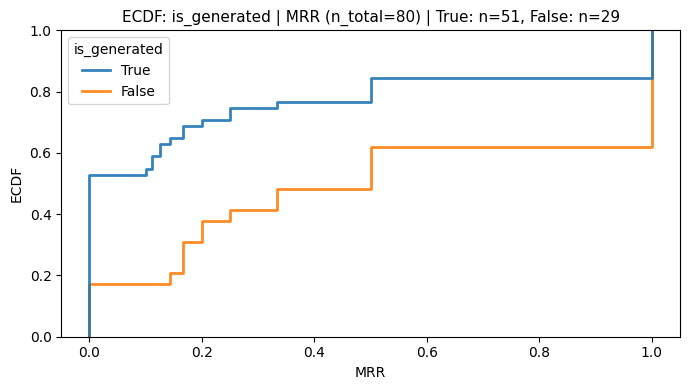

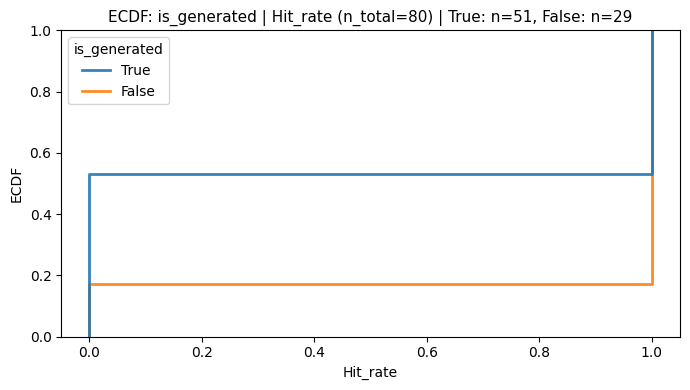

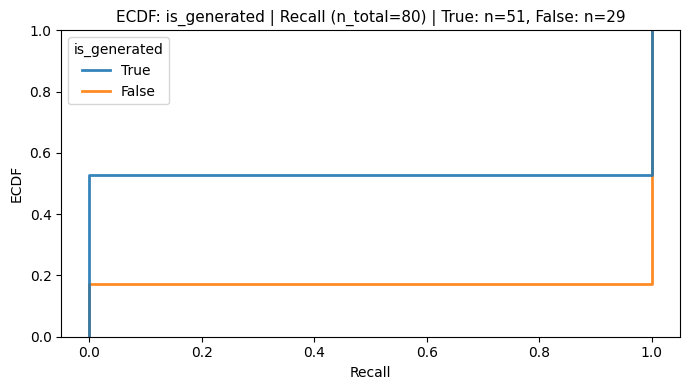

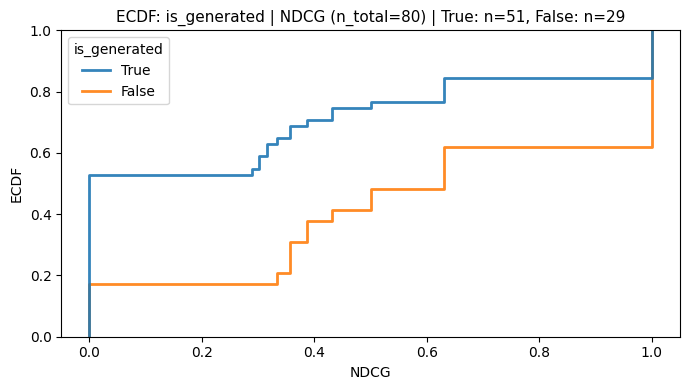

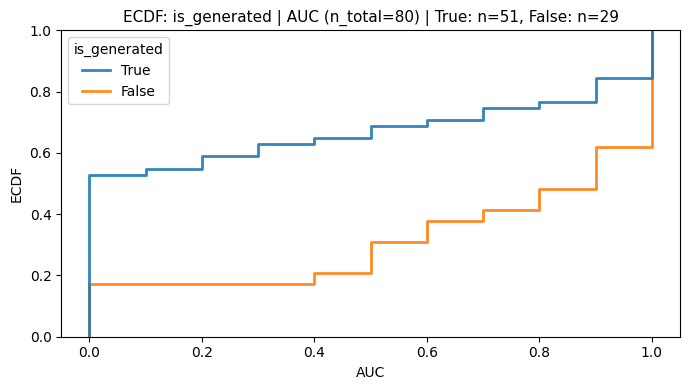

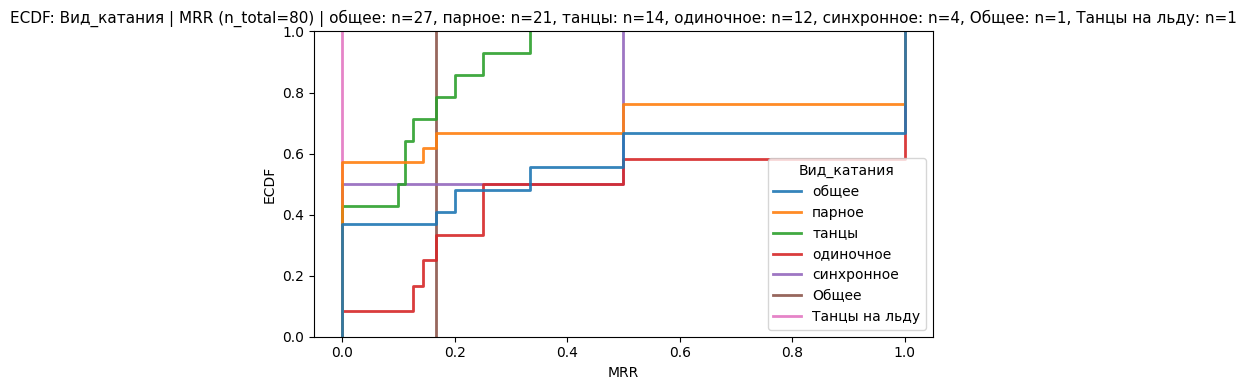

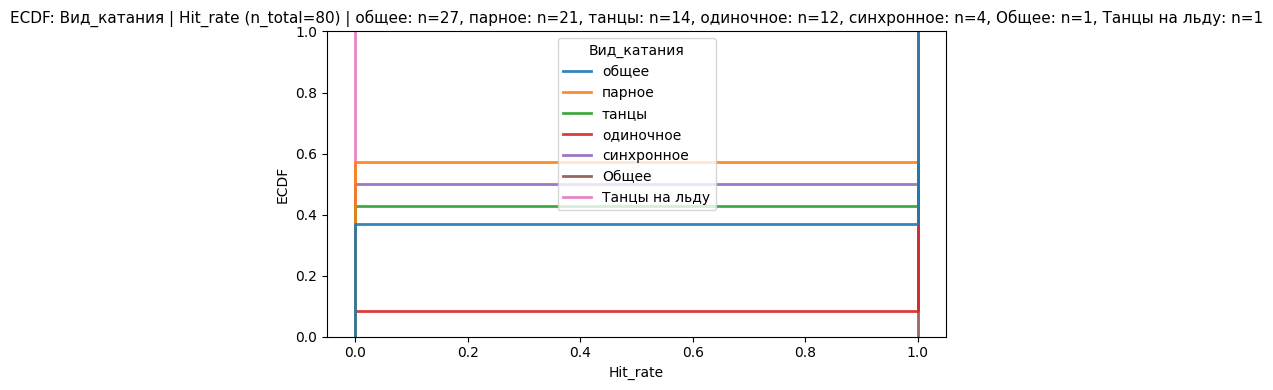

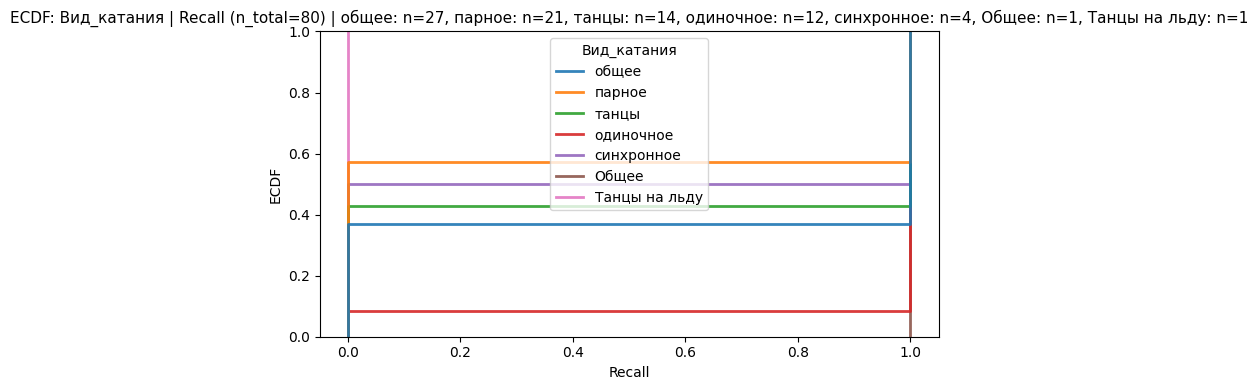

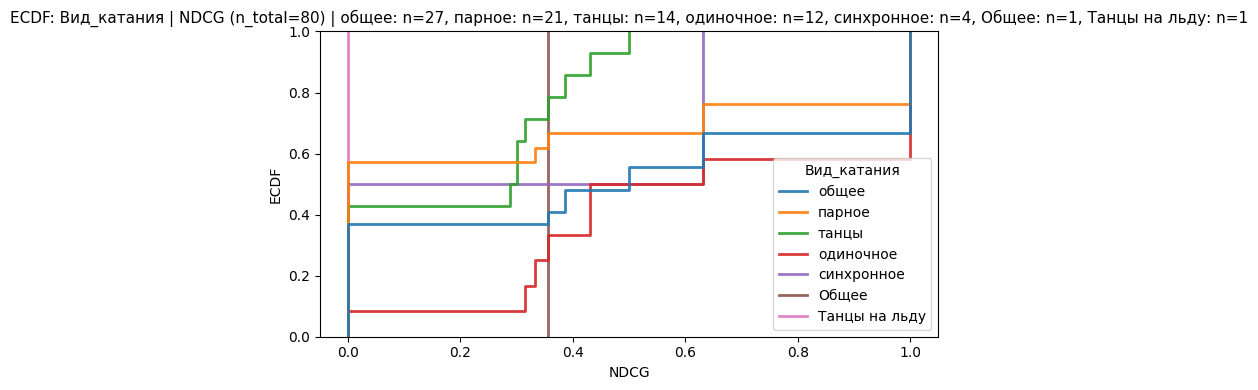

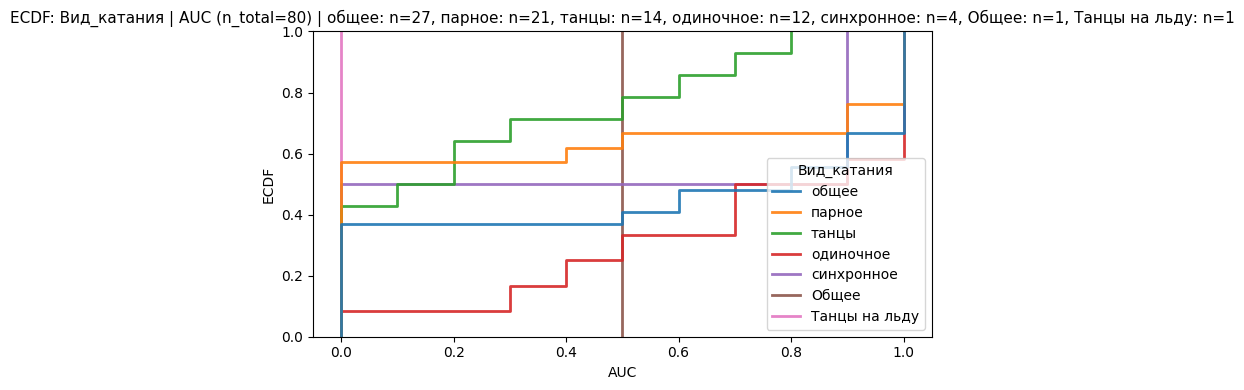

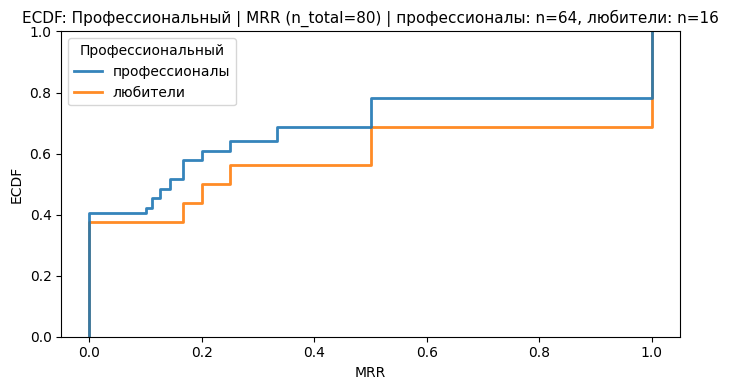

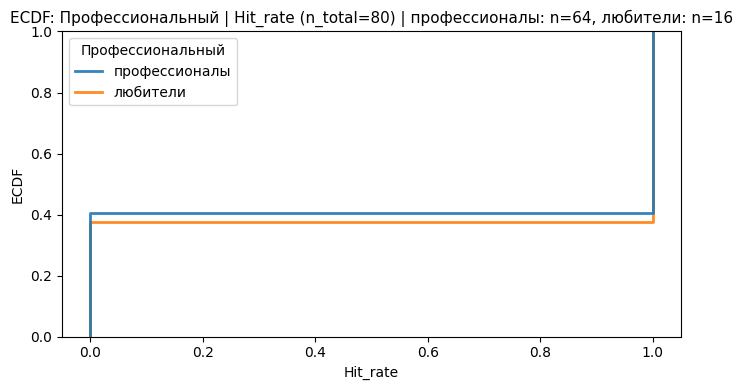

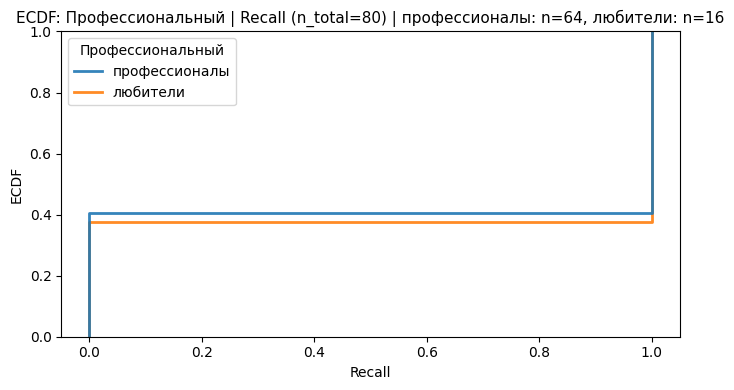

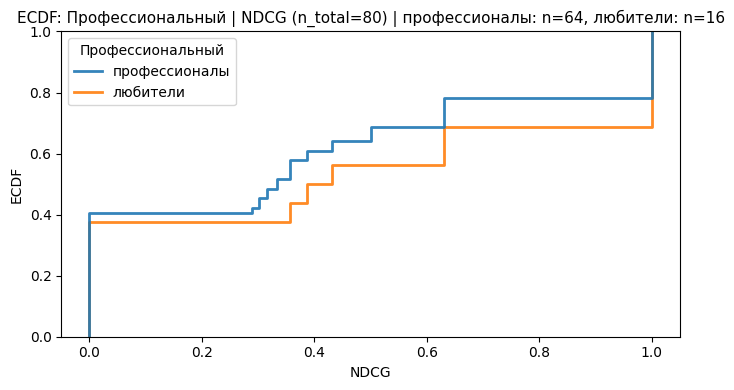

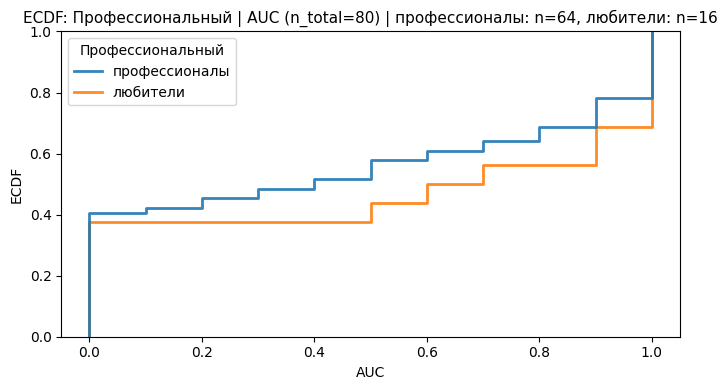

FileNotFoundError: [Errno 2] No such file or directory: 'figures/ecdf/Интернациональный/РФ/ecdf_Интернациональный/РФ_MRR.png'

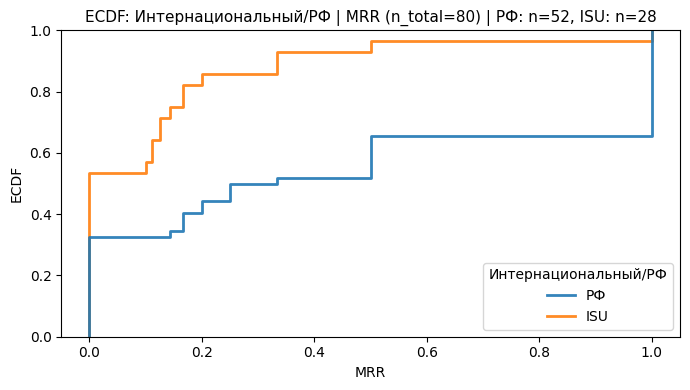

In [59]:
# ECDF распределения метрик по группам (по одному графику на метрику) + сохранение в папки
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

assert 'all_eval_df' in globals(), "Нет all_eval_df"

out_root = Path("figures/ecdf")
out_root.mkdir(parents=True, exist_ok=True)

group_cols = [
    'is_generated',
    'Вид_катания',
    'Профессиональный',
    'Интернациональный/РФ',
    'Кол-во_вопросов_в_запросе',
]
metric_cols = ['MRR', 'Hit_rate', 'Recall', 'NDCG', 'AUC']

for gc in group_cols:
    if gc not in all_eval_df.columns:
        print(f"Пропущено: {gc} — нет в all_eval_df")
        continue
    df_gc = all_eval_df.dropna(subset=metric_cols, how='all')
    if df_gc.empty:
        print(f"Пропущено: {gc} — все метрики NaN")
        continue
    n_total = len(df_gc)
    counts = df_gc[gc].value_counts().to_dict()
    hue_order = [k for k, _ in sorted(counts.items(), key=lambda x: -x[1])]
    palette = dict(zip(hue_order, sns.color_palette("tab10", n_colors=len(hue_order))))

    group_dir = out_root / gc
    group_dir.mkdir(parents=True, exist_ok=True)

    for m in metric_cols:
        if df_gc[m].dropna().empty:
            print(f"{gc} | {m}: нет данных")
            continue
        plt.figure(figsize=(7, 4))
        sns.ecdfplot(data=df_gc, x=m, hue=gc, hue_order=hue_order, palette=palette, linewidth=2, alpha=0.9)
        groups_n = ', '.join([f"{k}: n={v}" for k, v in counts.items()])
        plt.title(f"ECDF: {gc} | {m} (n_total={n_total}) | {groups_n}", fontsize=11)
        plt.xlabel(m)
        plt.ylabel('ECDF')
        plt.tight_layout()

        fname = f"ecdf_{gc}_{m}.png".replace(' ', '_')
        plt.savefig(group_dir / fname, dpi=200)
        plt.show()

